<a href="https://colab.research.google.com/github/ruso404/GEN-AI-EXPS/blob/main/GENAI_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.62MB/s]


Starting cGAN training...
Epoch [1/50], Step [200/469], D Loss: 1.2199, G Loss: 1.0039
Epoch [1/50], Step [400/469], D Loss: 1.1926, G Loss: 1.0471
Epoch [2/50], Step [200/469], D Loss: 1.0090, G Loss: 1.1056
Epoch [2/50], Step [400/469], D Loss: 0.6061, G Loss: 2.0268
Epoch [3/50], Step [200/469], D Loss: 1.0791, G Loss: 2.9771
Epoch [3/50], Step [400/469], D Loss: 0.7355, G Loss: 2.6276
Epoch [4/50], Step [200/469], D Loss: 1.0029, G Loss: 0.7979
Epoch [4/50], Step [400/469], D Loss: 0.8904, G Loss: 1.6526
Epoch [5/50], Step [200/469], D Loss: 0.6649, G Loss: 2.0298
Epoch [5/50], Step [400/469], D Loss: 0.8576, G Loss: 1.7081
Epoch [6/50], Step [200/469], D Loss: 1.0785, G Loss: 2.9911
Epoch [6/50], Step [400/469], D Loss: 0.7497, G Loss: 1.9031
Epoch [7/50], Step [200/469], D Loss: 0.8592, G Loss: 2.7413
Epoch [7/50], Step [400/469], D Loss: 0.9088, G Loss: 3.0916
Epoch [8/50], Step [200/469], D Loss: 1.2578, G Loss: 0.7860
Epoch [8/50], Step [400/469], D Loss: 0.8049, G Loss: 2.047

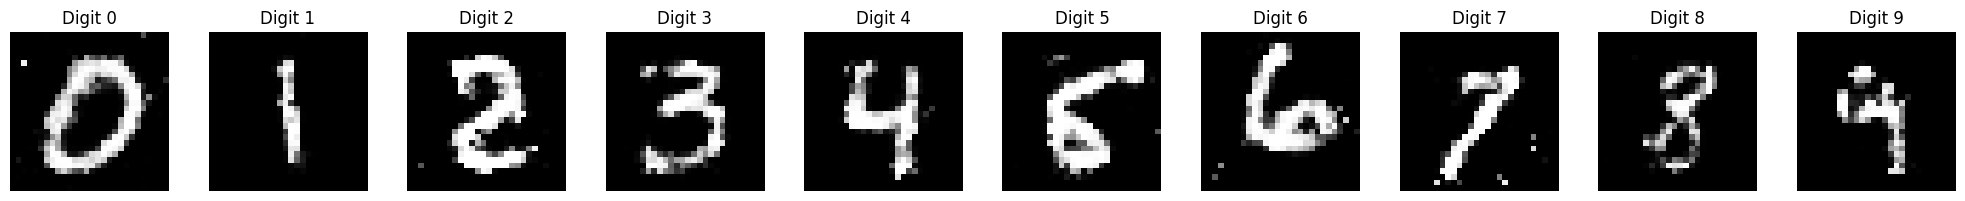

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# Reproducibility
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim, num_classes, image_size = 100, 10, 28*28
batch_size = 128
num_epochs = 50
# Small standard MNIST dataset (no huge dataset used)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_loader = DataLoader(datasets.MNIST('./data', True, transform, download=True), batch_size, shuffle=True)
class Generator(nn.Module):
 def __init__(self):
  super().__init__()
  self.label_emb = nn.Embedding(num_classes, num_classes)
  self.model = nn.Sequential(
   nn.Linear(latent_dim + num_classes, 256), nn.LeakyReLU(0.2),
   nn.Linear(256, 512), nn.LeakyReLU(0.2),
   nn.Linear(512, 1024), nn.LeakyReLU(0.2),
   nn.Linear(1024, image_size), nn.Tanh())
 def forward(self, z, labels):
  return self.model(torch.cat((z, self.label_emb(labels)), -1))
class Discriminator(nn.Module):
 def __init__(self):
  super().__init__()
  self.label_emb = nn.Embedding(num_classes, num_classes)
  self.model = nn.Sequential(
   nn.Linear(image_size + num_classes, 512), nn.LeakyReLU(0.2),
   nn.Linear(512, 256), nn.LeakyReLU(0.2),
   nn.Linear(256, 1), nn.Sigmoid())
 def forward(self, img, labels):
  return self.model(torch.cat((img.view(img.size(0),-1), self.label_emb(labels)), -1))
G = Generator().to(device)
D = Discriminator().to(device)
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
print("Starting cGAN training...")
for epoch in range(num_epochs):
 for step, (real_imgs, labels) in enumerate(train_loader):
  real_imgs = real_imgs.to(device)
  labels = labels.to(device)
  bs = real_imgs.size(0)
  # Train Discriminator
  z = torch.randn(bs, latent_dim).to(device)
  fake = G(z, labels)
  real_labels = torch.ones(bs, 1).to(device)
  fake_labels = torch.zeros(bs, 1).to(device)
  d_loss = criterion(D(real_imgs, labels), real_labels) + criterion(D(fake.detach(), labels), fake_labels)
  opt_D.zero_grad()
  d_loss.backward()
  opt_D.step()
  # Train Generator
  g_loss = criterion(D(G(torch.randn(bs, latent_dim).to(device), labels), labels), real_labels)
  opt_G.zero_grad()
  g_loss.backward()
  opt_G.step()
  # Exact progress print as in lab manual
  if (step + 1) % 200 == 0:
   print(f"Epoch [{epoch+1}/{num_epochs}], Step [{step+1}/{len(train_loader)}], D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
print("Training completed!")
# === SHOW GENERATED IMAGES (as per your requirement) ===
print("\nGenerating sample conditioned images (one per class 0-9)...")
fig, axs = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
 z = torch.randn(1, latent_dim).to(device)
 label = torch.tensor([i]).to(device)
 with torch.no_grad():
  fake = G(z, label)
  img = fake.view(28, 28).cpu().detach().numpy()
  axs[i].imshow(img, cmap='gray')
  axs[i].set_title(f"Digit {i}")
  axs[i].axis('off')
plt.tight_layout()
plt.show()